In [1]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
import optuna

c:\Users\kaitl\OneDrive\Documents\Icequake Modeling\Code\Icequake-QRC-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known = preprocess_data(filtered_time, data_orig)

In [3]:
# CatBoost
from catboost import CatBoostRegressor

# Avoiding any modification to original data sets since it uses column names and datatypes
X_train_cat = X_train.copy()
X_val_cat = X_val.copy()
X_test_cat = X_test.copy()

cat_features = X_train_cat.select_dtypes(include=["object", "category"]).columns.tolist()
#cat_features = ["high_t_evt"]
#Tuning CatBoost in Optuna using the same method as XGBoost
def objective_cat(trial):
  CatBoost = CatBoostRegressor(
      iterations = 100,
      learning_rate = trial.suggest_float("learning_rate",0.01,0.1,log=True),
      depth = trial.suggest_int("depth",2,8),
      loss_function = "RMSE",
      eval_metric = "RMSE",
      random_seed = 42,
      verbose=False,
      allow_writing_files=False,
      posterior_sampling=True,
      )

  CatBoost.fit(
      X_train_cat, y_train, eval_set=(X_val_cat, y_val),cat_features=cat_features, use_best_model=True)
  predictions_cat = CatBoost.predict(X_val_cat)
  RMSE_cat = root_mean_squared_error(y_val, predictions_cat)
  return RMSE_cat
optimization_cat= optuna.create_study(direction="minimize") #minimizing the above parameters
optimization_cat.optimize(objective_cat, n_trials=30) #keeping trails low for runtime and to prevent over-fitting noise

optimal_params_cat = optimization_cat.best_params
print("Optimal Parameters Cat:", optimal_params_cat)

#Running CatBoost with the optimal parameters
CatBoost = CatBoostRegressor(
    iterations = 100,
    **optimal_params_cat,
    loss_function = "RMSE",
    eval_metric = "RMSE",
    random_seed = 42,
    verbose=False,
    allow_writing_files=False
    )

CatBoost.fit(
    X_train_cat, y_train, eval_set=(X_val_cat, y_val),cat_features=cat_features, use_best_model=True)

# Calculating the multiplicative error
CatBoost_Prediction = CatBoost.predict(X_test_cat)
CatBoost_RMSE = root_mean_squared_error(y_test, CatBoost_Prediction)
CatBoost_Error = CatBoost_RMSE
print("CatBoost Error:", CatBoost_Error)

[I 2026-01-30 15:02:15,523] A new study created in memory with name: no-name-7d870555-252f-4478-ae30-da88e5a06f1e
[I 2026-01-30 15:02:15,822] Trial 0 finished with value: 24625.312708816855 and parameters: {'learning_rate': 0.02021942251676247, 'depth': 2}. Best is trial 0 with value: 24625.312708816855.
[I 2026-01-30 15:02:15,901] Trial 1 finished with value: 24661.845872856837 and parameters: {'learning_rate': 0.018681561865390668, 'depth': 2}. Best is trial 0 with value: 24625.312708816855.
[I 2026-01-30 15:02:16,031] Trial 2 finished with value: 24110.042567888788 and parameters: {'learning_rate': 0.015158695842534393, 'depth': 5}. Best is trial 2 with value: 24110.042567888788.
[I 2026-01-30 15:02:16,454] Trial 3 finished with value: 23998.81198829092 and parameters: {'learning_rate': 0.012805938398524409, 'depth': 8}. Best is trial 3 with value: 23998.81198829092.
[I 2026-01-30 15:02:16,821] Trial 4 finished with value: 23747.339581557753 and parameters: {'learning_rate': 0.01680

Optimal Parameters Cat: {'learning_rate': 0.07175924938471995, 'depth': 8}
CatBoost Error: 25728.588177296228


CatBoost Error: 25728.588177296228
Average Error per Record in seconds for Cat: 20796.579689844784
Sample0: True = 53550.00s, Predicted = 55046.22s, Error=1496.22s
Sample1: True = 83610.00s, Predicted = 53651.22s, Error=29958.78s
Sample2: True = 93015.00s, Predicted = 53275.60s, Error=39739.40s
Sample3: True = 73710.00s, Predicted = 55904.10s, Error=17805.90s
Sample4: True = 55650.00s, Predicted = 51367.61s, Error=4282.39s
Sample5: True = 38625.00s, Predicted = 59265.38s, Error=20640.38s
Sample6: True = 73170.00s, Predicted = 64657.92s, Error=8512.08s
Sample7: True = 55140.00s, Predicted = 47858.60s, Error=7281.40s
Sample8: True = 40740.00s, Predicted = 48779.07s, Error=8039.07s
Sample9: True = 75480.00s, Predicted = 57764.62s, Error=17715.38s
Sample10: True = 83955.00s, Predicted = 55362.34s, Error=28592.66s
Sample11: True = 87045.00s, Predicted = 57538.85s, Error=29506.15s
Sample12: True = 86970.00s, Predicted = 57696.26s, Error=29273.74s
Sample13: True = 90210.00s, Predicted = 62223

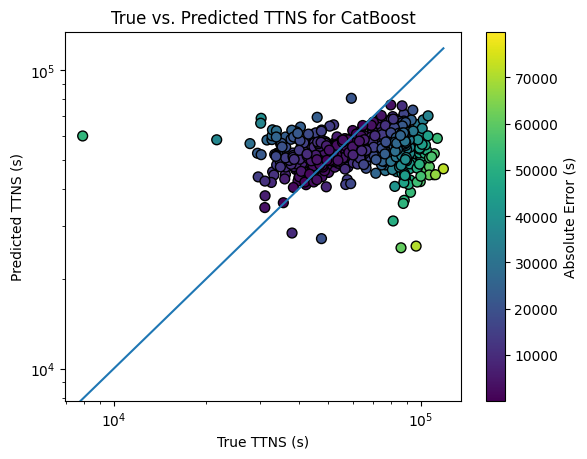

In [4]:
#Calculating multiplicative error for CatBoost
CatBoost_Prediction = CatBoost.predict(X_test_cat)
CatBoost_RMSE = root_mean_squared_error(y_test, CatBoost_Prediction)
CatBoost_Error = CatBoost_RMSE
print("CatBoost Error:", CatBoost_Error)

y_test_secs = y_test
Cat_pred_secs = CatBoost_Prediction

absolute_error_secs_Cat = np.abs(Cat_pred_secs - y_test_secs)

#absoulte_error_cat = np.abs(10**CatBoost_Prediction - y_test)
MAE_seconds = np.mean(absolute_error_secs_Cat)
print("Average Error per Record in seconds for Cat:", MAE_seconds)


#Calculating true value, predicted, and average error in terms of seconds for each event
for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, Cat_pred_secs, absolute_error_secs_Cat)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, Cat_pred_secs, c=absolute_error_secs_Cat, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for CatBoost")
plt.xscale('log')
plt.yscale('log')
plt.show()

Cat Boost Drivers: time_since     2648.908945
form_fac       2385.381316
slip_size      2270.032924
tide_deriv     1394.938674
tide_height    1236.714141
high_t_evt      681.967893
dtype: float64


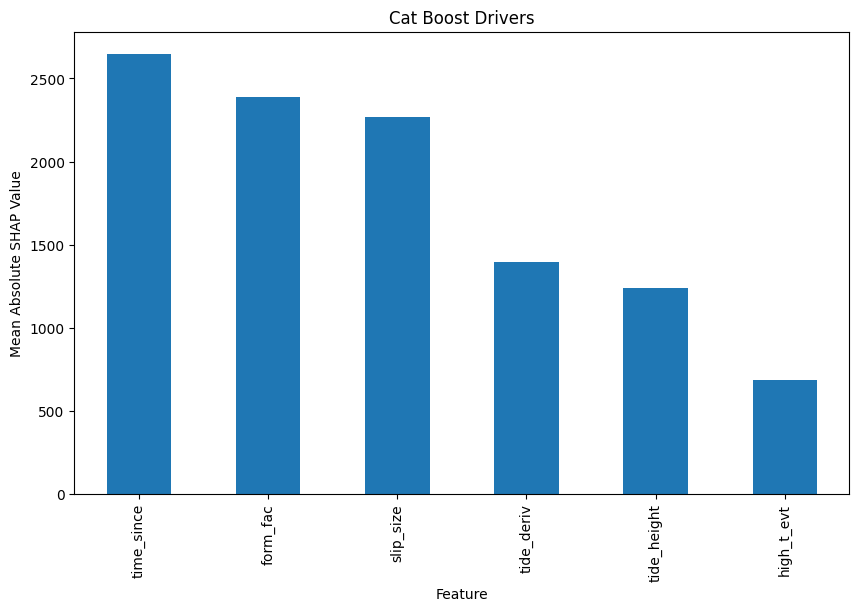

In [5]:
# Driving parameters for Cat

#Using the shap library with a copy of the training data to find the driving parameters
X_shap = X_test.copy()
explainer_cat = shap.TreeExplainer(CatBoost, X_shap, feature_perturbation="interventional")

shap_values_cat = explainer_cat.shap_values(X_shap)#Doing the tree analysis on Cat uisng training data

Cat_imp = pd.Series(np.abs(shap_values_cat).mean(axis=0), index=X_shap.columns).sort_values(ascending=False)#Analysis of driving parameters in Cat

print("Cat Boost Drivers:", Cat_imp)

# Creating a bar graph showing the driving parameters for CatBoost


plt.figure(figsize=(10, 6))
Cat_imp.sort_values(ascending=False).plot(kind="bar")
plt.title("Cat Boost Drivers")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Feature")
plt.show()